## 1. Foreword

Your problem statement will be the guiding force that will influence every question and decision making from this point onward. Before starting any of the exercises get that down.

It would be helpful to refresh the basics of statistical modelling and machine learnin before proceeding, here are the essential concepts that you should understand:

1. Exploratory Data Analysis (EDA):
    - Descriptive statistics (mean, median, variance, quantiles)
    - Understanding distributions and variability 

2. Data Pre-processing
    - Features & Target Transformation
    - Creating new features
    - Feature Selection

3. Regression Models: Linear Regression, Regularized Regression (Ridge, Lasso)
    - Interpreting coefficients, understanding R², MSE, MAE, RMSE

4. Classification Models: Logistic Regression, Decision Trees, Random Forests, SVMs, K-Nearest Neighbors
    - Interpreting probabilities, coefficients (log-odds), and feature importances

5. Evaluation Metrics:
    - For Regression: R², Mean Squared Error (MSE), Mean Absolute Error (MAE), Root Mean Squared Error (RMSE)
    - For Classification: Accuracy, Precision, Recall, F1 Score, ROC-AUC, and Confusion Matrix

6. Model Selection & Validation:
    - Train-test splits, cross-validation techniques
    - Overfitting vs. underfitting
    - Hyperparameter tuning (grid search, random search)

7. Model Interpretability & Explainability:
    - Interpreting model coefficients and feature importance
    - Visualization of decision trees (using plot_tree)
    - Tools like SHAP and LIME for local/global explanations



#### The entire Data Science process would look something like:

1. Exploration: Start with EDA to understand your data. Ask questions about distributions, correlations, and anomalies.
2. Modeling:Build models using core algorithms, evaluate with relevant metrics, and examine model outputs (coefficients, feature importances).
3. Evaluation:Compare metrics against baselines, inspect errors, and assess whether the model meets the problem requirements.
4. Iteration:Use insights from the evaluation to refine feature engineering, adjust preprocessing steps, or try different models.
5. Repeat: Go through this process again—exploration, modeling, evaluation—until you reach the desired balance between performance, interpretability, and practical applicability, based on your problem statement


## 2. Assignment Tasks

1) Define a problem statement
2) Perform EDA (if you are choosing a new dataset)
3) Use EDA Insights for feature selection and feature engineering
4) Create your first 3 models using the framework I provide
5) Evaluate the model and then attempt to improve it
6) Interpret Model results and outputs (coefficients, trees) and continue to add to your insights.
7) Explore 2 new models of your choice. Some suggestions are KNN, SVM for classification & Ridge, Lasso for regression but there are so many more and part of the fun of data science is researching new ways to do things.


Please note that the tasks above are guidelines and this is more of an art than a science. Your specific problem might require some specialized techniques and steps. I implore you to question every characteristic of your dataset and models you encounter and ask "how can I use this to give me insights?" and "what technique can I apply to this to make it useful?".

Good luck and feel free to reach out with any questions.

## 3. Resources
1. Concise explanation for popular Machine learning models : https://www.youtube.com/watch?v=E0Hmnixke2g 
2. Fantastic sklearn algorithms cheat sheet : https://scikit-learn.org/stable/machine_learning_map.html
    - This sklearn tutorial by the sklearn team is amazing too : https://scikit-learn.org/1.4/tutorial/index.html
3. The Python Data Science handbook I linked last assignment has a great machine learning section that should help clear any basics.

These should help you get started but the best way to learn is start the process and when you encounter something you don't fully understand, look that up specifically and apply it. 

## 4. Predictive Modelling (Your Assignment Should be Below)

For reference, below is working code roughly following the guidelines and using the same dataset from the last couple sessions.

### Cleaning & Pre-Processing

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

# For combining pipelines after encoding
from sklearn.compose import make_column_selector as selector

sns.set(style="whitegrid")

In [88]:
df = pd.read_csv("Smartphone_Usage_Productivity_Dataset_50000.csv")

df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    50000 non-null  str    
 1   Age                        50000 non-null  int64  
 2   Gender                     50000 non-null  str    
 3   Occupation                 50000 non-null  str    
 4   Device_Type                50000 non-null  str    
 5   Daily_Phone_Hours          50000 non-null  float64
 6   Social_Media_Hours         50000 non-null  float64
 7   Work_Productivity_Score    50000 non-null  int64  
 8   Sleep_Hours                50000 non-null  float64
 9   Stress_Level               50000 non-null  int64  
 10  App_Usage_Count            50000 non-null  int64  
 11  Caffeine_Intake_Cups       50000 non-null  int64  
 12  Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(4), int64(5), str(4)
memory usage: 5.0 MB


,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,39.034960,6.509116,4.267250,5.503760,6.497744,5.504500,32.43898,3.004580,8.006844
std,12.414877,3.170903,2.164743,2.874806,1.449551,2.871095,16.12151,1.996657,3.461300
min,18.000000,1.000000,0.500000,1.000000,4.000000,1.000000,5.00000,0.000000,2.000000
25%,28.000000,3.800000,2.400000,3.000000,5.200000,3.000000,18.00000,1.000000,5.000000
50%,39.000000,6.500000,4.300000,5.500000,6.500000,6.000000,32.00000,3.000000,8.000000
75%,50.000000,9.200000,6.100000,8.000000,7.800000,8.000000,46.00000,5.000000,11.000000
max,60.000000,12.000000,8.000000,10.000000,9.000000,10.000000,60.00000,6.000000,14.000000


#Classification Target

In [89]:
df["Productivity_Level"] = pd.cut(
    df["Work_Productivity_Score"],
    bins=[0, 4, 5, 10],
    labels=["Low", "Medium", "High"]
)

In [90]:
df["Productivity_Level"].value_counts()

Productivity_Level
High      25000
Low       19921
Medium     5079
Name: count, dtype: int64

Some Basic Cleaning

In [91]:
df.columns = df.columns.str.replace(" ","_")
df.fillna(df.median(numeric_only=True), inplace=True)


,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,Productivity_Level
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7,High
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1,Medium
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3,Medium
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8,Low
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,U49996,44,Male,Business Owner,Android,5.9,5.4,5,6.6,1,11,5,3.0,Medium
49996,U49997,42,Other,Business Owner,Android,2.9,7.4,9,6.3,2,20,4,6.2,High
49997,U49998,27,Female,Freelancer,iOS,1.4,2.5,4,6.7,9,39,4,5.1,Low
49998,U49999,41,Female,Business Owner,iOS,8.9,3.0,6,5.5,2,51,0,9.2,High


Generating Continuous Data to use regression

- Missing occupation, likely unemployed or self-emplployed? 
- missing workclass : likely the same set? 
- missing native country : could be bi-racial or just missing in the survey/input methodology

choosing to keep the missing values

In [92]:
df.fillna('?',inplace=True)

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,Productivity_Level
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7,High
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1,Medium
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3,Medium
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8,Low
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,U49996,44,Male,Business Owner,Android,5.9,5.4,5,6.6,1,11,5,3.0,Medium
49996,U49997,42,Other,Business Owner,Android,2.9,7.4,9,6.3,2,20,4,6.2,High
49997,U49998,27,Female,Freelancer,iOS,1.4,2.5,4,6.7,9,39,4,5.1,Low
49998,U49999,41,Female,Business Owner,iOS,8.9,3.0,6,5.5,2,51,0,9.2,High


In [93]:
#Features

In [94]:
target = "Productivity_Level"
features = [
    "Daily_Phone_Hours",
    "Social_Media_Hours",
    "Sleep_Hours",
    "Age"
]

X = df[features]
y = df["Productivity_Level"]

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### A. Regression Models

In [96]:
# --- Linear Regression ---
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [97]:

# --- Decision Tree Regressor ---
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [98]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

### B. Classification Models


In [99]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.5031
Decision Tree Accuracy: 0.412
Random Forest Accuracy: 0.4689


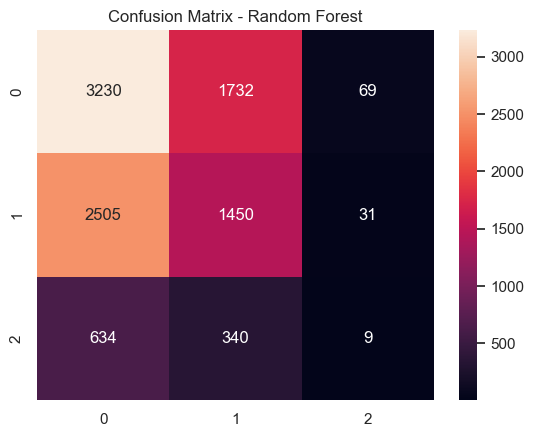

In [100]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

### C. Interpreting Results

#### Regression Coefficients

The coefficients are interpreted as "the change in the target associated with a unit change in that variable, if all else remains the same". 
- A higher positive value means the feature has a strong positive association with the target.
- A negative value means the feature is inversely associated with the target.
- This helps in understanding which predictors have the most influence on your continuous target variable.

#### Log Odds for Logistic Regression

The sign and magnitude of each log-odds coefficient indicate how a one-unit change in the feature affects the log odds of being in the positive class.

#### Visualizing a Decision Tree

Decision Tree Accuracy: 0.412

Classification Report:
              precision    recall  f1-score   support

        High       0.50      0.48      0.49      5031
         Low       0.40      0.40      0.40      3986
      Medium       0.09      0.11      0.10       983

    accuracy                           0.41     10000
   macro avg       0.33      0.33      0.33     10000
weighted avg       0.42      0.41      0.42     10000



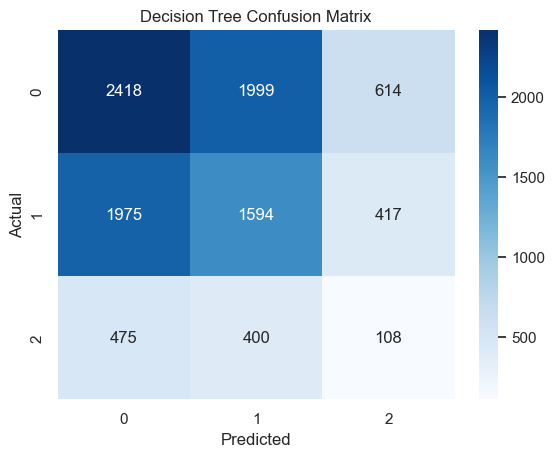

In [101]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Accuracy: 0.4689

Classification Report:
              precision    recall  f1-score   support

        High       0.51      0.64      0.57      5031
         Low       0.41      0.36      0.39      3986
      Medium       0.08      0.01      0.02       983

    accuracy                           0.47     10000
   macro avg       0.33      0.34      0.32     10000
weighted avg       0.43      0.47      0.44     10000



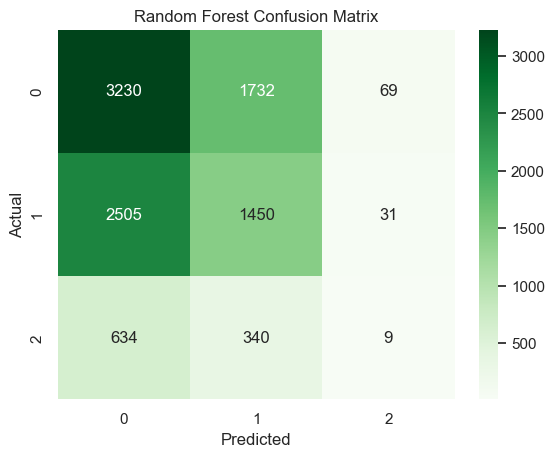

In [102]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Hyperparameter Tuning

In [103]:
from sklearn.model_selection import GridSearchCV

# parameter grid
param_grid = {
    "max_depth": [3,5,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

# grid search
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_dt.fit(X_train, y_train)

print("Best Decision Tree Parameters:")
print(grid_dt.best_params_)

Best Decision Tree Parameters:
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [104]:
best_dt = grid_dt.best_estimator_

y_pred_best_dt = best_dt.predict(X_test)

print("Tuned Decision Tree Accuracy:", accuracy_score(y_test, y_pred_best_dt))

Tuned Decision Tree Accuracy: 0.5028


conclusions
The original productivity score was converted into categorical productivity levels (Low, Medium, High) in order to frame the prediction problem as a classification task so i can identify patterns that differentiate productivity groups rather than predicting an exact numerical score. Daily phone hours and sleep hours appear to play the most significant role in predicting productivity level. Individuals with higher phone usage and lower sleep hours tend to fall into lower productivity categories. The Random Forest classifier performed best after hyperparameter tuning, achieving the highest accuracy. Feature importance analysis indicates that daily phone hours and sleep hours play the largest role in predicting productivity level.
